# Convergence test for the IMEX-mr-SAV-RK solver

This notebook follows the structure of `01_convergence_test.ipynb` in the ETD-mr-SAV-MS2 folder, but uses the fixed-step solver implemented in `imex_mrsav_rk_solver.py`.  The default configuration is intentionally moderate so that the notebook can be run quickly; increase `NX`, `NY`, `T_FINAL`, and `REF_EXPONENT` for production-level convergence data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from imex_mrsav_rk_solver import (
    HAS_FFTW,
    make_periodic_ops,
    solve_fixed_step,
    poisson_solve,
    velocity_from_vorticity,
)

np.random.seed(1)

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "Times New Roman",
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

print(f"pyFFTW: {HAS_FFTW}")


pyFFTW: True


In [2]:
# Problem and experiment parameters.
nu    = 1 / 50
gamma = 1000.0
m     = 1

DOMAIN = (0.0, 0.0, 2 * np.pi, 2 * np.pi)
NX, NY = 64, 64
T_FINAL = 0.2

# The tested time steps are dt = TAU_BASE * 2^{-k}.
# Choose T_FINAL / TAU_BASE as an integer so every tested dt reaches T_FINAL exactly.
TAU_BASE = 1.0e-2
EXPONENTS = [3, 4, 5, 6, 7, 8, 9, 10]

# Reference solution: computed by RK4 with dt_ref = TAU_BASE * 2^{-REF_EXPONENT}.
# Increase this value when using larger grids or when measuring the finest RK4 errors.
REF_METHOD = "rk4"
REF_EXPONENT = 11

# Optional warm-up, similar in spirit to the source notebook.  Keep 0 for a quick test.
WARMUP_T = 0.0
WARMUP_DT = 1.0e-3

scheme_configs = [
    ("rk1", "IMEX-mr-SAV-RK1", "#D55E00", "s", "--", 1),
    ("rk2", "IMEX-mr-SAV-RK2", "#0072B2", "o", "-", 2),
    ("rk3", "IMEX-mr-SAV-RK3", "#009E73", "^", "-.", 3),
    ("rk4", "IMEX-mr-SAV-RK4", "#CC79A7", "D", ":", 4),
]

FIG_DIR = Path("fig")
FIG_DIR.mkdir(exist_ok=True)


In [3]:
def force_term(X, Y, t):
    """Vorticity forcing used in the convergence test."""
    return m * np.cos(m * X)


def initial_streamfunction(x, y, eps=2.5, k_max=10):
    """Isotropic Fourier perturbation used to build a smooth initial field."""
    perturbation = np.zeros_like(x, dtype=np.float64)
    for k1 in range(-k_max, k_max + 1):
        for k2 in range(-k_max, k_max + 1):
            k_abs = np.sqrt(k1 * k1 + k2 * k2)
            if k_abs < 1e-14 or k_abs > k_max:
                continue
            perturbation += (
                (np.cos(k1 * x) + np.sin(k1 * x))
                * (np.cos(k2 * y) + np.sin(k2 * y))
                / k_abs**3
            )
    return eps * perturbation


def omega_from_streamfunction(ops, psi):
    """Convert streamfunction to vorticity using omega = -Delta psi."""
    psi_hat = ops.fft2(psi)
    omega = ops.ifft2(-ops.Lap * psi_hat).real
    omega -= np.mean(omega)
    return omega


def fields_from_omega(ops, omega):
    psi = poisson_solve(ops, omega)
    u, v = velocity_from_vorticity(ops, omega)
    return psi, u, v


def l2_norm(ops, value):
    return np.sqrt(ops.cell_area * np.sum(value * value))


def l2_error(ops, value, reference):
    return l2_norm(ops, value - reference)


In [4]:
# Build the initial vorticity.
ops = make_periodic_ops(DOMAIN, (NX, NY))
psi_initial = initial_streamfunction(ops.X, ops.Y)
omega_initial = omega_from_streamfunction(ops, psi_initial)

if WARMUP_T > 0:
    warmup = solve_fixed_step(
        omega_initial,
        q0=1.0,
        nu=nu,
        gamma=gamma,
        domain=DOMAIN,
        discrete_num=(NX, NY),
        dt=WARMUP_DT,
        t_span=(0.0, WARMUP_T),
        method="rk3",
        force=force_term,
        save_every=int(round(WARMUP_T / WARMUP_DT)),
        keep_omega=True,
    )
    omega_initial = warmup.omega[-1]

print("initial mean(omega) =", np.mean(omega_initial))
print("initial max |omega| =", np.max(np.abs(omega_initial)))

initial mean(omega) = -3.3306690738754696e-16
initial max |omega| = 148.01469450067057


In [5]:
# Compute a reference solution using the finest RK4 step.
dt_ref = TAU_BASE * 2.0 ** (-REF_EXPONENT)
N_ref = int(round(T_FINAL / dt_ref))
assert np.isclose(N_ref * dt_ref, T_FINAL)

print(f"reference method: {REF_METHOD}, dt_ref = {dt_ref:.3e}, N_ref = {N_ref}")

reference_result = solve_fixed_step(
    omega_initial,
    q0=1.0,
    nu=nu,
    gamma=gamma,
    domain=DOMAIN,
    discrete_num=(NX, NY),
    dt=dt_ref,
    t_span=(0.0, T_FINAL),
    method=REF_METHOD,
    force=force_term,
    save_every=N_ref,
    keep_omega=True,
    print_progress=True,
)

omega_ref = reference_result.omega[-1]
psi_ref, u_ref, v_ref = fields_from_omega(ops, omega_ref)
q_ref = reference_result.q[-1]

reference_data = {
    "omega": omega_ref,
    "psi": psi_ref,
    "u": u_ref,
    "v": v_ref,
    "q": q_ref,
}

print(f"q_ref = {q_ref:.12e}")
print(f"reference enstrophy = {reference_result.enstrophy[-1]:.12e}")


reference method: rk4, dt_ref = 4.883e-06, N_ref = 40960
t=0.200000/0.200000, q=9.99949139e-01, E=7.43942351e+02, Ens=1.86793873e+03, Newton=1, step=0.0024s, total=102.59s
q_ref = 9.999491390651e-01
reference enstrophy = 1.867938730203e+03


In [6]:
def compute_orders(taus, errors):
    orders = np.full_like(errors, np.nan, dtype=np.float64)
    for i in range(1, len(errors)):
        if taus[i] > 0 and taus[i - 1] > 0 and errors[i] > 0 and errors[i - 1] > 0:
            orders[i] = np.log(errors[i - 1] / errors[i]) / np.log(taus[i - 1] / taus[i])
    return orders


def run_one_method(method, label, exponents):
    rows = []
    for exponent in exponents:
        dt = TAU_BASE * 2.0 ** (-exponent)
        nsteps = int(round(T_FINAL / dt))
        assert np.isclose(nsteps * dt, T_FINAL), (dt, nsteps * dt, T_FINAL)

        result = solve_fixed_step(
            omega_initial,
            q0=1.0,
            nu=nu,
            gamma=gamma,
            domain=DOMAIN,
            discrete_num=(NX, NY),
            dt=dt,
            t_span=(0.0, T_FINAL),
            method=method,
            force=force_term,
            save_every=nsteps,
            keep_omega=True,
            print_progress=True,
        )

        omega = result.omega[-1]
        psi, u, v = fields_from_omega(ops, omega)
        rows.append({
            "exponent": exponent,
            "N": nsteps,
            "tau": dt,
            "omega": l2_error(ops, omega, reference_data["omega"]),
            "psi": l2_error(ops, psi, reference_data["psi"]),
            "u": np.sqrt(l2_error(ops, u, reference_data["u"])**2 + l2_error(ops, v, reference_data["v"])**2),
            "q": abs(result.q[-1] - 1.0),
            "q_ref_error": abs(result.q[-1] - reference_data["q"]),
            "energy": result.energy[-1],
            "enstrophy": result.enstrophy[-1],
        })

    data = {key: np.array([row[key] for row in rows]) for key in rows[0]}
    for key in ("omega", "psi", "u", "q", "q_ref_error"):
        data[f"ord_{key}"] = compute_orders(data["tau"], data[key])
    return data


def run_convergence_experiment(exponents=EXPONENTS):
    results = {}
    for method, label, *_ in scheme_configs:
        print(label)
        results[label] = run_one_method(method, label, exponents)
    return results


def print_convergence_rates(result, label, component="omega"):
    print(label)
    for i, (tau, err) in enumerate(zip(result["tau"], result[component])):
        if i == 0:
            print(f"  tau = {tau:.2e}, err = {err:.3e}")
        else:
            rate = result[f"ord_{component}"][i]
            print(f"  tau = {tau:.2e}, err = {err:.3e}, rate = {rate:.2f}")


In [7]:
results_fixed = run_convergence_experiment(EXPONENTS)


IMEX-mr-SAV-RK1
t=0.200000/0.200000, q=9.26513460e-01, E=7.43963729e+02, Ens=1.87021264e+03, Newton=1, step=0.0007s, total=0.11s
t=0.200000/0.200000, q=9.91226309e-01, E=7.43951028e+02, Ens=1.86863692e+03, Newton=1, step=0.0007s, total=0.23s
t=0.200000/0.200000, q=9.96848681e-01, E=7.43946385e+02, Ens=1.86824551e+03, Newton=1, step=0.0007s, total=0.42s
t=0.200000/0.200000, q=9.98604357e-01, E=7.43944304e+02, Ens=1.86808412e+03, Newton=1, step=0.0007s, total=0.85s
t=0.200000/0.200000, q=9.99326693e-01, E=7.43943312e+02, Ens=1.86800968e+03, Newton=1, step=0.0007s, total=1.71s
t=0.200000/0.200000, q=9.99656608e-01, E=7.43942828e+02, Ens=1.86797382e+03, Newton=1, step=0.0007s, total=3.40s
t=0.200000/0.200000, q=9.99814501e-01, E=7.43942588e+02, Ens=1.86795621e+03, Newton=1, step=0.0007s, total=6.87s
t=0.200000/0.200000, q=9.99891766e-01, E=7.43942469e+02, Ens=1.86794749e+03, Newton=1, step=0.0007s, total=13.90s
IMEX-mr-SAV-RK2
t=0.200000/0.200000, q=9.94685589e-01, E=7.43942339e+02, Ens=1.

In [8]:
for _, label, *_ in scheme_configs:
    print_convergence_rates(results_fixed[label], label, component="omega")
    print()

IMEX-mr-SAV-RK1
  tau = 1.25e-03, err = 1.707e+00
  tau = 6.25e-04, err = 5.030e-01, rate = 1.76
  tau = 3.13e-04, err = 2.133e-01, rate = 1.24
  tau = 1.56e-04, err = 9.975e-02, rate = 1.10
  tau = 7.81e-05, err = 4.862e-02, rate = 1.04
  tau = 3.91e-05, err = 2.430e-02, rate = 1.00
  tau = 1.95e-05, err = 1.245e-02, rate = 0.96
  tau = 9.77e-06, err = 6.635e-03, rate = 0.91

IMEX-mr-SAV-RK2
  tau = 1.25e-03, err = 2.153e-02
  tau = 6.25e-04, err = 5.403e-03, rate = 1.99
  tau = 3.13e-04, err = 1.352e-03, rate = 2.00
  tau = 1.56e-04, err = 3.372e-04, rate = 2.00
  tau = 7.81e-05, err = 8.357e-05, rate = 2.01
  tau = 3.91e-05, err = 2.044e-05, rate = 2.03
  tau = 1.95e-05, err = 4.829e-06, rate = 2.08
  tau = 9.77e-06, err = 1.055e-06, rate = 2.19

IMEX-mr-SAV-RK3
  tau = 1.25e-03, err = 9.093e-04
  tau = 6.25e-04, err = 1.153e-04, rate = 2.98
  tau = 3.13e-04, err = 1.450e-05, rate = 2.99
  tau = 1.56e-04, err = 1.817e-06, rate = 3.00
  tau = 7.81e-05, err = 2.271e-07, rate = 3.00
  

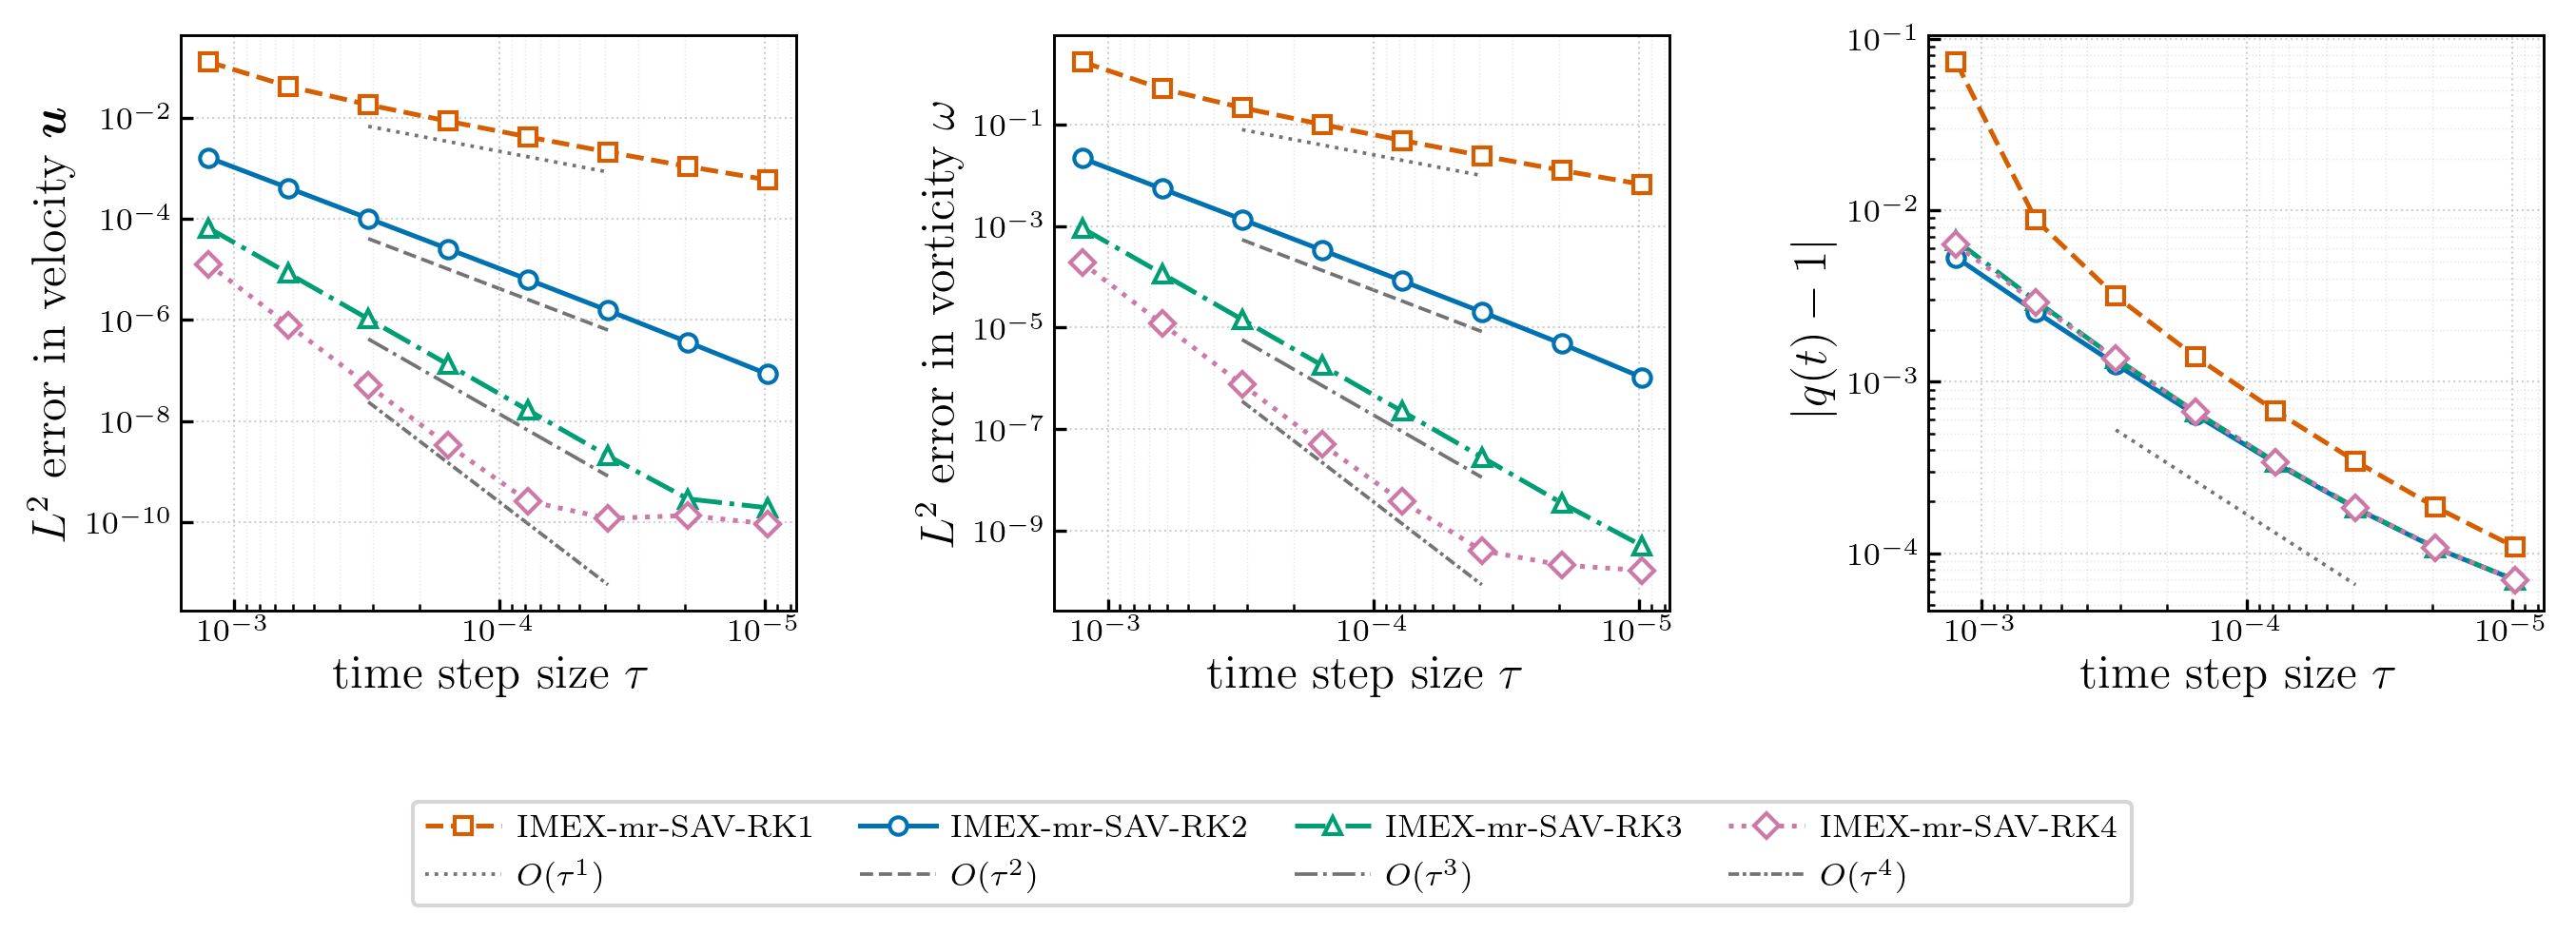

In [9]:
def plot_convergence_results(results, save_path=None, title=""):
    rc = {
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "axes.linewidth": 0.7,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "xtick.minor.size": 1.6,
        "ytick.minor.size": 1.6,
        "savefig.dpi": 600,
        "pdf.fonttype": 42,        # editable (TrueType) text in the PDF
        "ps.fonttype": 42,
    }

    # Neutral-grey convergence-order guide lines, one dash pattern per order so
    # the legend entries stay distinguishable.
    GUIDE_DASHES = {1: ":", 2: "--", 3: "-.", 4: (0, (3, 1, 1, 1))}
    GUIDE_COLOR = "0.45"
    GUIDE_OFFSET = 2.5   # sit ~0.4 decade (about 2.5x) below the curve

    def order_guide(ax, tau, err, order, *, label, offset=GUIDE_OFFSET):
        tau = np.asarray(tau, dtype=float)
        err = np.asarray(err, dtype=float)
        n = len(tau)
        j = n // 2
        lo_a, hi_a = j - 1, j                       # the two middle points
        # Log (geometric) mean anchor of the middle two points, shifted down by
        # `offset` so the guide sits just below the error curve.
        log_tau_m = 0.5 * (np.log(tau[lo_a]) + np.log(tau[hi_a]))
        log_err_m = 0.5 * (np.log(err[lo_a]) + np.log(err[hi_a]))
        c = np.exp(log_err_m - np.log(offset)) / np.exp(order * log_tau_m)
        # Draw a segment over the central intervals so the slope is clear.
        lo = max(0, j - 2)
        hi = min(n - 1, j + 1)
        tt = np.array([tau[lo], tau[hi]])
        ax.loglog(
            tt, c * tt ** order,
            color=GUIDE_COLOR, linestyle=GUIDE_DASHES[order], linewidth=0.9,
            label=label, zorder=1,
        )

    with plt.rc_context(rc):
        fig, axes = plt.subplots(1, 3, figsize=(9, 3.2), dpi=300)
        panel_specs = [
            ("u", r"$L^2$ error in velocity $\boldsymbol{u}$"),
            ("omega", r"$L^2$ error in vorticity $\omega$"),
            ("q", r"$|q(t)-1|$"),
        ]

        for panel_id, (ax, (key, ylabel)) in enumerate(zip(axes, panel_specs)):
            add_legend_labels = panel_id == 0
            for method, label, color, marker, ls, expected_order in scheme_configs:
                r = results[label]
                # Single call: solid coloured line with open white-filled markers.
                ax.loglog(
                    r["tau"], r[key],
                    color=color, linestyle=ls, linewidth=1.2,
                    marker=marker, markersize=4.4,
                    markerfacecolor="white", markeredgewidth=1.0,
                    markeredgecolor=color,
                    label=label if add_legend_labels else "_nolegend_",
                    zorder=3,
                )
                # Per-curve order guide below each error line (u and omega panels).
                if key in ("u", "omega"):
                    order_guide(
                        ax, r["tau"], r[key], expected_order,
                        label=(rf"$O(\tau^{{{expected_order}}})$"
                               if add_legend_labels else "_nolegend_"),
                    )

            # |q(T)-1| is first order for every scheme: a single guide below all
            # curves is enough (legend already carries O(tau^1) from the u panel).
            if key == "q":
                q_stack = np.array([results[label]["q"] for _, label, *_ in scheme_configs])
                q_min = q_stack.min(axis=0)
                order_guide(ax, results[scheme_configs[0][1]]["tau"], q_min, 1,
                            label="_nolegend_")

            ax.set_xlabel(r"time step size $\tau$", labelpad=2)
            ax.set_ylabel(ylabel, labelpad=3)
            ax.grid(True, which="major", linestyle=":", linewidth=0.5, alpha=0.6)
            ax.grid(True, which="minor", linestyle=":", linewidth=0.35, alpha=0.3)
            ax.invert_xaxis()
            ax.tick_params(axis="both", which="major", labelsize=8, pad=2)
            ax.tick_params(axis="both", which="minor", labelsize=7, pad=2)
            # Panel tag in the upper-left corner.

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            loc="lower center", bbox_to_anchor=(0.5, 0.0),
            ncol=4, fontsize=8,
            handlelength=2.4, columnspacing=1.4, handletextpad=0.5,
        )

        if title:
            fig.suptitle(title, y=0.99, fontsize=9)
        fig.subplots_adjust(left=0.075, right=0.995,
                            top=0.93 if title else 0.97,
                            bottom=0.34, wspace=0.42)
        if save_path is not None:
            fig.savefig(save_path, bbox_inches="tight", pad_inches=0.02)
    return fig, axes

fig, axes = plot_convergence_results(
    results_fixed,
    save_path=FIG_DIR / "imex_mrsav_rk_convergence_fixed.pdf",
    title="",
)
plt.show()
